# Dashboard Personal — Índice Cognitivo Diario (ICD)

Visualización de métricas biométricas, calidad de sueño y estado cognitivo.

**Datos:** Suunto wearable + autoevaluación subjetiva → `metrics.db`

---

In [1]:
# ============================================================
# Setup e importaciones
# ============================================================
import sys
from pathlib import Path

# Añadir raíz del proyecto al path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from datetime import date, timedelta
from sqlmodel import Session, select

from src.bio.db import get_engine
from src.bio.models import DailyBiometrics

# Estilo global
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'axes.edgecolor': '#3a3f4b',
    'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.alpha': 0.6,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})

# Paleta de colores
C_ACCENT = '#58a6ff'   # azul principal
C_GREEN  = '#3fb950'   # positivo / peak
C_YELLOW = '#d29922'   # normal
C_ORANGE = '#db6d28'   # fatigue
C_RED    = '#f85149'   # burnout
C_PURPLE = '#bc8cff'   # subjetivo
C_CYAN   = '#39d2c0'   # sueño
C_GRID   = '#21262d'

print('Setup completado.')

Setup completado.


In [2]:
# ============================================================
# Cargar datos de la BD
# ============================================================
engine = get_engine()

with Session(engine) as session:
    records = session.exec(
        select(DailyBiometrics).order_by(DailyBiometrics.date.asc())
    ).all()

# Convertir a DataFrame
data = []
for r in records:
    data.append({
        'date': r.date,
        'hrv_rmssd': r.hrv_rmssd,
        'ln_rmssd': r.ln_rmssd,
        'hrv_baseline_7d': r.hrv_baseline_7d,
        'resting_hr': r.resting_hr,
        'avg_hr_sleep': r.avg_hr_sleep,
        'sleep_total_min': r.sleep_total_min,
        'deep_sleep_min': r.deep_sleep_min,
        'rem_sleep_min': r.rem_sleep_min,
        'light_sleep_min': r.light_sleep_min,
        'awake_min': r.awake_min,
        'sleep_start_time': r.sleep_start_time,
        'sleep_quality': r.sleep_quality,
        'sleep_consistency': r.sleep_consistency,
        'body_resources': r.body_resources,
        'training_load': r.training_load,
        'energy_level': r.energy_level,
        'mental_clarity': r.mental_clarity,
        'mood': r.mood,
        'motivation': r.motivation,
        'muscle_soreness': r.muscle_soreness,
        'icd_score': r.icd_score,
    })

df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Horas de sueño (para graficar más legible)
df['sleep_hours'] = df['sleep_total_min'] / 60.0

# Hora de dormir en formato numérico para graficar
def time_str_to_hour(t: str) -> float:
    """Convierte HH:MM a hora decimal. Después de medianoche se suma 24."""
    if pd.isna(t) or t is None:
        return np.nan
    h, m = map(int, t.split(':'))
    hour = h + m / 60
    # Si la hora es antes de las 12, es madrugada → sumar 24 para ordenar bien
    if hour < 12:
        hour += 24
    return hour

df['bedtime_hour'] = df['sleep_start_time'].apply(time_str_to_hour)

print(f'Registros cargados: {len(df)}')
print(f'Rango: {df.index.min().date()} → {df.index.max().date()}')
df.tail(3)

Registros cargados: 14
Rango: 2026-01-31 → 2026-02-13


,hrv_rmssd,ln_rmssd,hrv_baseline_7d,resting_hr,avg_hr_sleep,sleep_total_min,deep_sleep_min,rem_sleep_min,light_sleep_min,awake_min,...,body_resources,training_load,energy_level,mental_clarity,mood,motivation,muscle_soreness,icd_score,sleep_hours,bedtime_hour
date,,,,,,,,,,,,,,,,,,,,,
2026-02-11,57.0,4.043051,3.950357,64,63.0,446,112,75,258,0,...,76.0,5.0,NaN,NaN,None,NaN,NaN,56.429691,7.433333,26.666667
2026-02-12,82.0,4.406719,4.074767,52,54.0,475,98,148,220,0,...,88.0,6.0,6.0,8.0,focused,9.0,2.0,65.813259,7.916667,26.966667
2026-02-13,63.0,4.143135,4.091859,58,60.0,460,120,74,250,0,...,72.0,6.0,5.0,6.0,tired,4.0,4.0,55.634132,7.666667,27.333333


---
## 1. ICD — Evolución Temporal con Zonas Cognitivas

El ICD determina qué tipo de trabajo cognitivo puedes abordar cada día:
- **>80 (Peak):** Deep Work — temas nuevos, matemáticas
- **50–80 (Normal):** Flow — programación, ejercicios estándar
- **30–50 (Fatigue):** Review — repaso espaciado, lectura
- **<30 (Burnout):** Survival — solo contenido pasivo

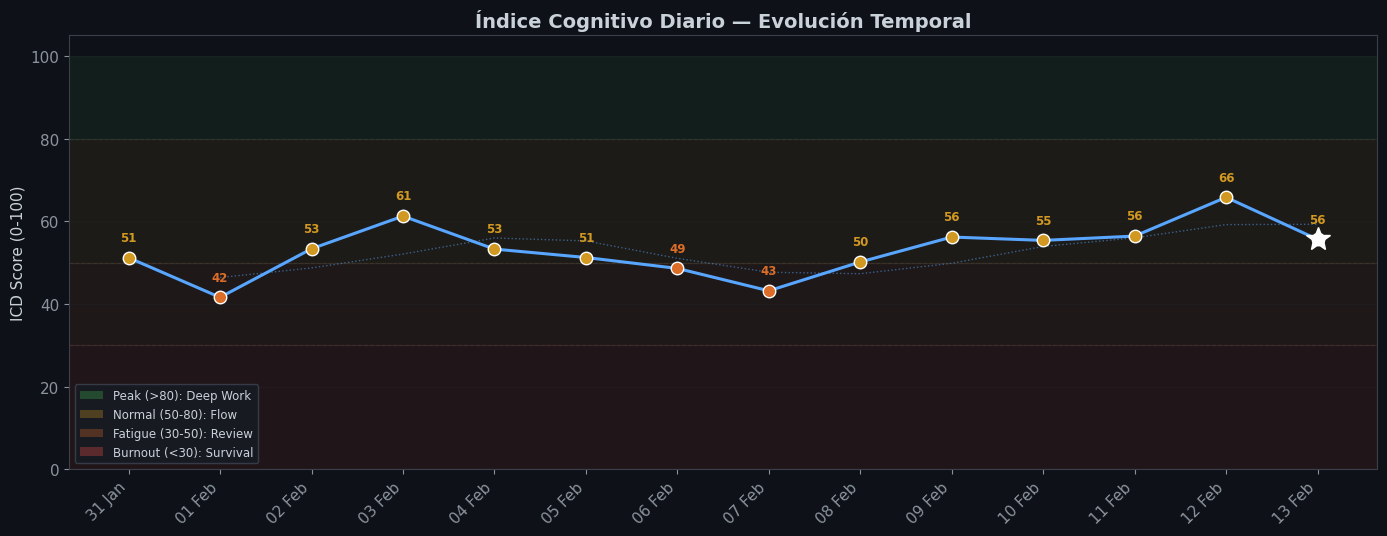


  HOY (2026-02-13):  ICD = 55.6  →  NORMAL ⚡


In [3]:
fig, ax = plt.subplots(figsize=(14, 5.5))

# Zonas de fondo
ax.axhspan(80, 100, color=C_GREEN, alpha=0.08, label='Peak (>80)')
ax.axhspan(50, 80,  color=C_YELLOW, alpha=0.08, label='Normal (50-80)')
ax.axhspan(30, 50,  color=C_ORANGE, alpha=0.08, label='Fatigue (30-50)')
ax.axhspan(0,  30,  color=C_RED, alpha=0.08, label='Burnout (<30)')

# Líneas de umbral
for threshold in [30, 50, 80]:
    ax.axhline(y=threshold, color='#3a3f4b', linewidth=0.8, linestyle='--', alpha=0.5)

# Línea ICD
icd_vals = df['icd_score'].dropna()
ax.plot(icd_vals.index, icd_vals.values, color=C_ACCENT, linewidth=2.2, marker='o',
        markersize=7, markerfacecolor=C_ACCENT, markeredgecolor='white', markeredgewidth=1.2,
        zorder=5, label='ICD Score')

# Colorear cada punto según su zona
for dt, val in icd_vals.items():
    if val > 80:
        c = C_GREEN
    elif val >= 50:
        c = C_YELLOW
    elif val >= 30:
        c = C_ORANGE
    else:
        c = C_RED
    ax.plot(dt, val, 'o', color=c, markersize=9, zorder=6, markeredgecolor='white', markeredgewidth=1)
    ax.annotate(f'{val:.0f}', (dt, val), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=8.5, fontweight='bold', color=c)

# Destacar hoy
today = pd.Timestamp(date.today())
if today in icd_vals.index:
    today_icd = icd_vals[today]
    ax.plot(today, today_icd, '*', color='white', markersize=18, zorder=7)

# Media móvil 3 días
if len(icd_vals) >= 3:
    rolling_icd = icd_vals.rolling(3, min_periods=2).mean()
    ax.plot(rolling_icd.index, rolling_icd.values, color=C_ACCENT, linewidth=1, 
            linestyle=':', alpha=0.5, label='Media móvil 3d')

ax.set_ylim(0, 105)
ax.set_ylabel('ICD Score (0-100)')
ax.set_title('Índice Cognitivo Diario — Evolución Temporal')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Leyenda
legend_patches = [
    mpatches.Patch(facecolor=C_GREEN, alpha=0.3, label='Peak (>80): Deep Work'),
    mpatches.Patch(facecolor=C_YELLOW, alpha=0.3, label='Normal (50-80): Flow'),
    mpatches.Patch(facecolor=C_ORANGE, alpha=0.3, label='Fatigue (30-50): Review'),
    mpatches.Patch(facecolor=C_RED, alpha=0.3, label='Burnout (<30): Survival'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=8.5, 
          facecolor='#161b22', edgecolor='#3a3f4b', framealpha=0.9)

plt.tight_layout()
plt.show()

# Resumen de hoy
if today in icd_vals.index:
    v = icd_vals[today]
    zona = 'PEAK 🔥' if v > 80 else 'NORMAL ⚡' if v >= 50 else 'FATIGUE ⚠️' if v >= 30 else 'BURNOUT 🛑'
    print(f'\n  HOY ({today.date()}):  ICD = {v:.1f}  →  {zona}')

---
## 2. HRV — ln(RMSSD) vs Baseline Personal

La línea naranja (EMA 7d) es tu **línea base personal**. Los días donde ln_rmssd está por encima significan mejor recuperación que tu normal; por debajo, peor.

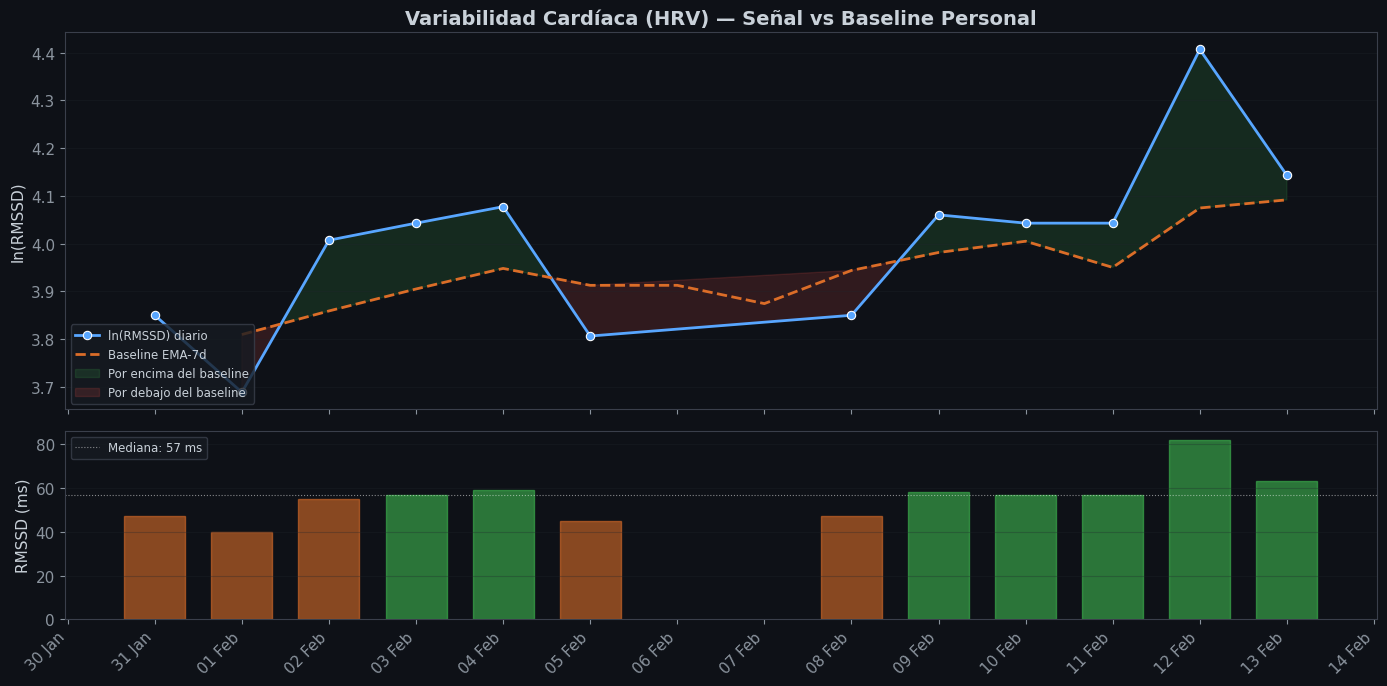

  HRV media: 55.6 ms  |  Mediana: 57 ms  |  Rango: 40–82 ms


In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), height_ratios=[2, 1], sharex=True)

# ---- Panel superior: ln_rmssd vs baseline ----
ln_vals = df['ln_rmssd'].dropna()
bl_vals = df['hrv_baseline_7d'].dropna()

ax1.plot(ln_vals.index, ln_vals.values, color=C_ACCENT, linewidth=2, marker='o',
         markersize=6, markeredgecolor='white', markeredgewidth=0.8, label='ln(RMSSD) diario')
ax1.plot(bl_vals.index, bl_vals.values, color=C_ORANGE, linewidth=2, linestyle='--',
         label='Baseline EMA-7d')

# Rellenar entre curvas
common_idx = ln_vals.index.intersection(bl_vals.index)
ln_common = ln_vals[common_idx]
bl_common = bl_vals[common_idx]

ax1.fill_between(common_idx, ln_common, bl_common,
                 where=(ln_common >= bl_common), interpolate=True,
                 color=C_GREEN, alpha=0.15, label='Por encima del baseline')
ax1.fill_between(common_idx, ln_common, bl_common,
                 where=(ln_common < bl_common), interpolate=True,
                 color=C_RED, alpha=0.15, label='Por debajo del baseline')

ax1.set_ylabel('ln(RMSSD)')
ax1.set_title('Variabilidad Cardíaca (HRV) — Señal vs Baseline Personal')
ax1.legend(loc='lower left', fontsize=8.5, facecolor='#161b22', edgecolor='#3a3f4b')
ax1.grid(axis='y', alpha=0.3)

# ---- Panel inferior: HRV crudo en ms ----
hrv_raw = df['hrv_rmssd'].dropna()
bars = ax2.bar(hrv_raw.index, hrv_raw.values, width=0.7, color=C_ACCENT, alpha=0.7, edgecolor='none')

# Colorear barras
median_hrv = hrv_raw.median()
for bar, val in zip(bars, hrv_raw.values):
    bar.set_color(C_GREEN if val >= median_hrv else C_ORANGE)
    bar.set_alpha(0.6)

ax2.axhline(median_hrv, color='white', linewidth=0.8, linestyle=':', alpha=0.5, label=f'Mediana: {median_hrv:.0f} ms')
ax2.set_ylabel('RMSSD (ms)')
ax2.set_xlabel('')
ax2.legend(loc='upper left', fontsize=8.5, facecolor='#161b22', edgecolor='#3a3f4b')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Stats rápidos
print(f'  HRV media: {hrv_raw.mean():.1f} ms  |  Mediana: {median_hrv:.0f} ms  |  Rango: {hrv_raw.min():.0f}–{hrv_raw.max():.0f} ms')

---
## 3. Sueño — Arquitectura, Consistencia y Hora de Dormir

El sueño es el predictor más fuerte de rendimiento cognitivo. Aquí se analiza:
- **Arquitectura:** proporción deep / REM / light
- **Hora de dormir:** regularidad circadiana (¿te acuestas a la misma hora?)
- **Sleep Consistency:** desviación estándar del horario — valores altos = caos circadiano

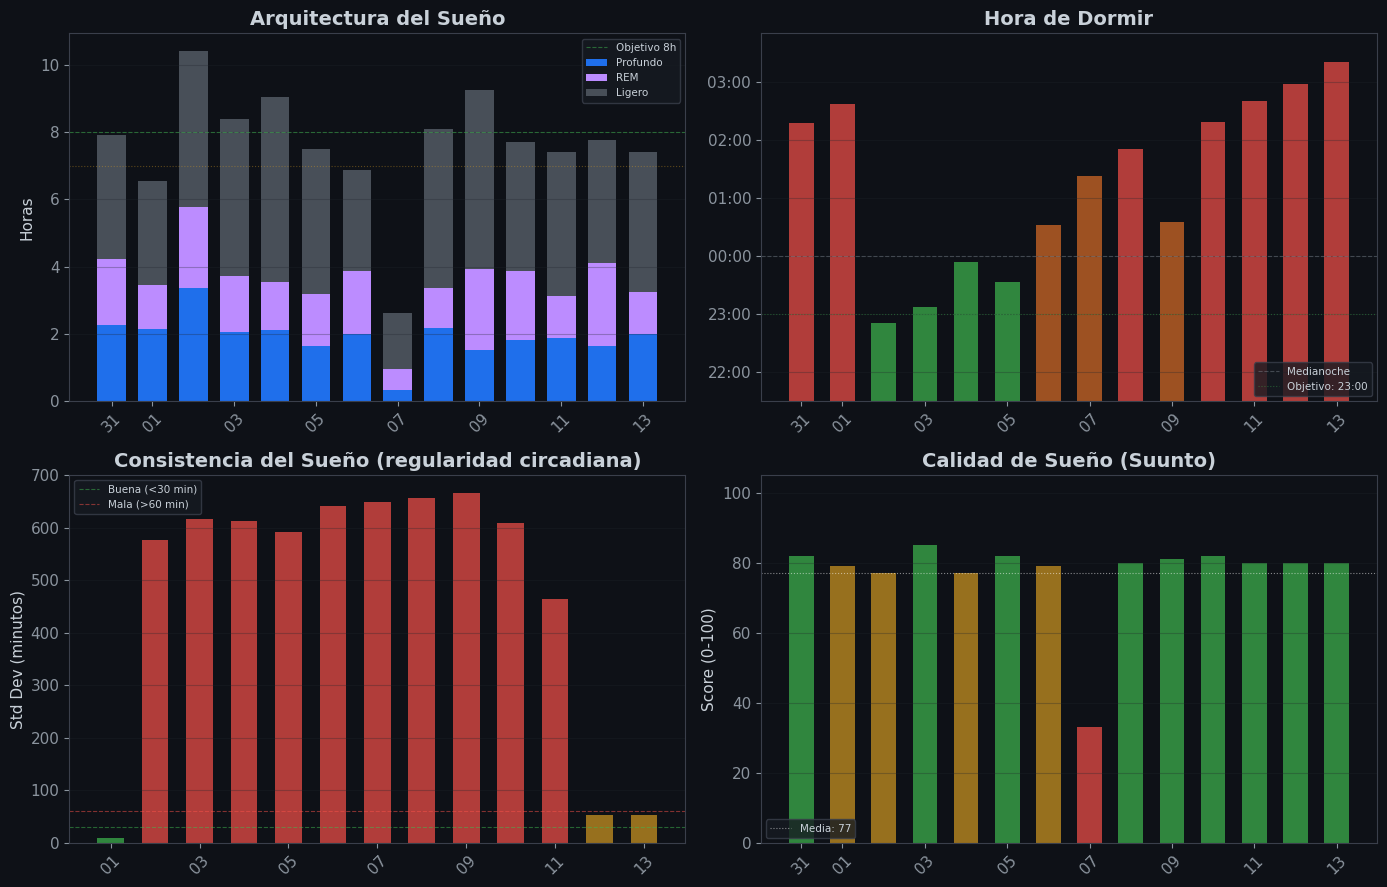

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ---- (1) Arquitectura del sueño: stacked bars ----
ax = axes[0, 0]
sleep_cols = df[['deep_sleep_min', 'rem_sleep_min', 'light_sleep_min']].dropna()
if not sleep_cols.empty:
    # Convertir a horas
    deep_h = sleep_cols['deep_sleep_min'] / 60
    rem_h = sleep_cols['rem_sleep_min'] / 60
    light_h = sleep_cols['light_sleep_min'] / 60
    
    width = 0.7
    ax.bar(sleep_cols.index, deep_h, width, color='#1f6feb', label='Profundo', edgecolor='none')
    ax.bar(sleep_cols.index, rem_h, width, bottom=deep_h, color=C_PURPLE, label='REM', edgecolor='none')
    ax.bar(sleep_cols.index, light_h, width, bottom=deep_h + rem_h, color='#484f58', label='Ligero', edgecolor='none')
    
    # Línea de referencia 8h
    ax.axhline(8, color=C_GREEN, linewidth=0.8, linestyle='--', alpha=0.5, label='Objetivo 8h')
    ax.axhline(7, color=C_YELLOW, linewidth=0.8, linestyle=':', alpha=0.4)

ax.set_ylabel('Horas')
ax.set_title('Arquitectura del Sueño')
ax.legend(loc='upper right', fontsize=7.5, facecolor='#161b22', edgecolor='#3a3f4b')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
ax.grid(axis='y', alpha=0.3)

# ---- (2) Hora de dormir ----
ax = axes[0, 1]
bed = df['bedtime_hour'].dropna()
if not bed.empty:
    colors_bed = [C_GREEN if 22 <= h <= 24.5 else C_ORANGE if h <= 25.5 else C_RED for h in bed.values]
    ax.bar(bed.index, bed.values, width=0.6, color=colors_bed, alpha=0.7, edgecolor='none')
    ax.axhline(24, color='#8b949e', linewidth=0.8, linestyle='--', alpha=0.4, label='Medianoche')
    ax.axhline(23, color=C_GREEN, linewidth=0.8, linestyle=':', alpha=0.4, label='Objetivo: 23:00')
    
    # Convertir eje Y a formato hora legible
    yticks = [22, 23, 24, 25, 26, 27]
    ylabels = ['22:00', '23:00', '00:00', '01:00', '02:00', '03:00']
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_ylim(21.5, max(bed.values) + 0.5)

ax.set_title('Hora de Dormir')
ax.legend(loc='lower right', fontsize=7.5, facecolor='#161b22', edgecolor='#3a3f4b')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
ax.grid(axis='y', alpha=0.3)

# ---- (3) Sleep Consistency (std dev hora dormir) ----
ax = axes[1, 0]
sc = df['sleep_consistency'].dropna()
if not sc.empty:
    colors_sc = [C_GREEN if v <= 30 else C_YELLOW if v <= 60 else C_RED for v in sc.values]
    ax.bar(sc.index, sc.values, width=0.6, color=colors_sc, alpha=0.7, edgecolor='none')
    ax.axhline(30, color=C_GREEN, linewidth=0.8, linestyle='--', alpha=0.5, label='Buena (<30 min)')
    ax.axhline(60, color=C_RED, linewidth=0.8, linestyle='--', alpha=0.5, label='Mala (>60 min)')

ax.set_ylabel('Std Dev (minutos)')
ax.set_title('Consistencia del Sueño (regularidad circadiana)')
ax.legend(loc='upper left', fontsize=7.5, facecolor='#161b22', edgecolor='#3a3f4b')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
ax.grid(axis='y', alpha=0.3)

# ---- (4) Sleep Quality (Suunto score) ----
ax = axes[1, 1]
sq = df['sleep_quality'].dropna()
if not sq.empty:
    colors_sq = [C_GREEN if v >= 80 else C_YELLOW if v >= 60 else C_ORANGE if v >= 40 else C_RED for v in sq.values]
    ax.bar(sq.index, sq.values, width=0.6, color=colors_sq, alpha=0.7, edgecolor='none')
    ax.axhline(sq.mean(), color='white', linewidth=0.8, linestyle=':', alpha=0.5, label=f'Media: {sq.mean():.0f}')

ax.set_ylabel('Score (0-100)')
ax.set_title('Calidad de Sueño (Suunto)')
ax.set_ylim(0, 105)
ax.legend(loc='lower left', fontsize=7.5, facecolor='#161b22', edgecolor='#3a3f4b')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
ax.grid(axis='y', alpha=0.3)

for a in axes.flat:
    a.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 4. Body Resources & Frecuencia Cardíaca en Reposo

- **Body Resources** (Suunto): índice integrado de recuperación. Es una de las features más importantes del ICD.
- **Resting HR**: cuanto más baja, mejor estado cardiovascular. Picos indican fatiga o estrés.

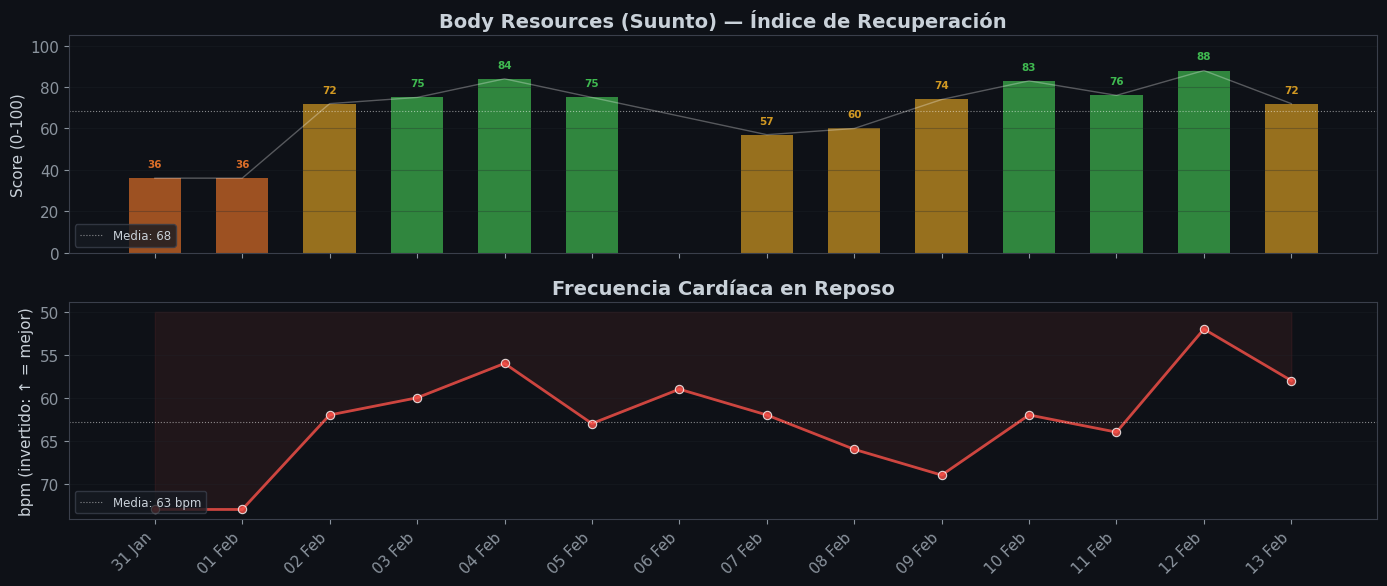

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# ---- Body Resources ----
br = df['body_resources'].dropna()
if not br.empty:
    colors_br = [C_GREEN if v >= 75 else C_YELLOW if v >= 50 else C_ORANGE if v >= 30 else C_RED for v in br.values]
    ax1.bar(br.index, br.values, width=0.6, color=colors_br, alpha=0.7, edgecolor='none')
    ax1.plot(br.index, br.values, color='white', linewidth=1, alpha=0.3)
    ax1.axhline(br.mean(), color='white', linewidth=0.8, linestyle=':', alpha=0.5, label=f'Media: {br.mean():.0f}')
    
    # Anotar valores
    for dt, val in br.items():
        c = C_GREEN if val >= 75 else C_YELLOW if val >= 50 else C_ORANGE
        ax1.annotate(f'{val:.0f}', (dt, val), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=7.5, color=c, fontweight='bold')

ax1.set_ylabel('Score (0-100)')
ax1.set_title('Body Resources (Suunto) — Índice de Recuperación')
ax1.set_ylim(0, 105)
ax1.legend(loc='lower left', fontsize=8.5, facecolor='#161b22', edgecolor='#3a3f4b')
ax1.grid(axis='y', alpha=0.3)

# ---- Resting HR ----
rhr = df['resting_hr'].dropna()
if not rhr.empty:
    ax2.plot(rhr.index, rhr.values, color=C_RED, linewidth=2, marker='o',
             markersize=6, markeredgecolor='white', markeredgewidth=0.8, alpha=0.8)
    ax2.fill_between(rhr.index, rhr.values, rhr.values.min() - 2, color=C_RED, alpha=0.08)
    ax2.axhline(rhr.mean(), color='white', linewidth=0.8, linestyle=':', alpha=0.5, label=f'Media: {rhr.mean():.0f} bpm')
    ax2.invert_yaxis()  # Menor HR = mejor → arriba

ax2.set_ylabel('bpm (invertido: ↑ = mejor)')
ax2.set_title('Frecuencia Cardíaca en Reposo')
ax2.legend(loc='lower left', fontsize=8.5, facecolor='#161b22', edgecolor='#3a3f4b')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Correlación Rápida — ¿Qué influye más en el ICD?

Mapa de calor de correlaciones entre métricas clave y el ICD. Esto anticipa el análisis completo de la Tarea 3.7.

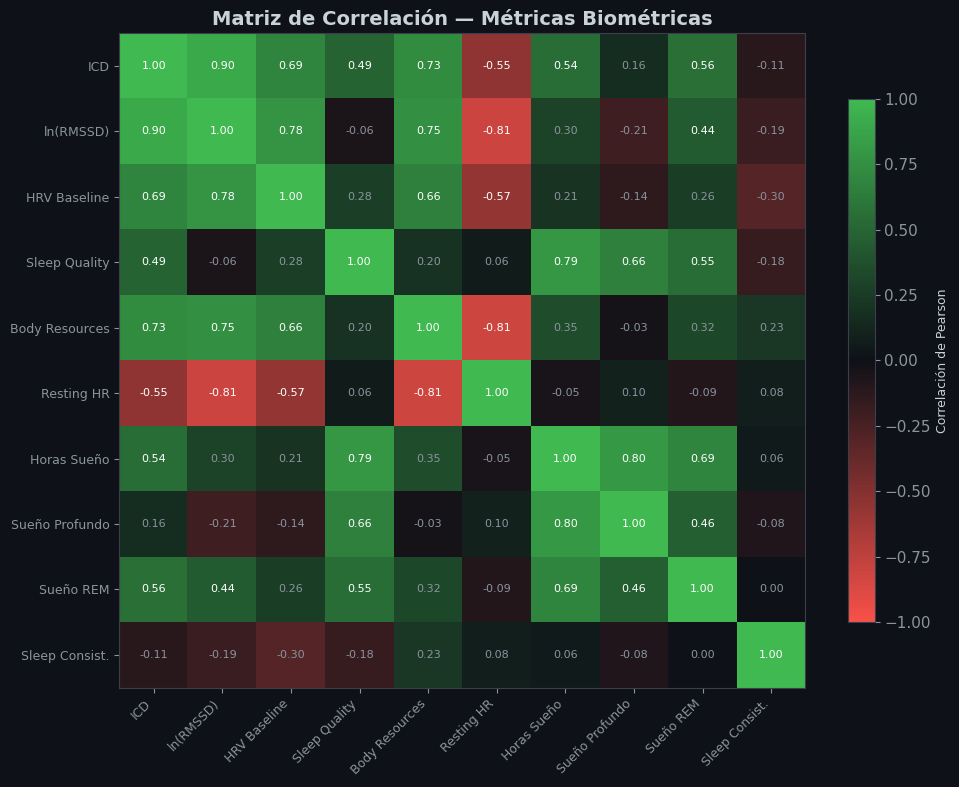


Correlaciones con ICD (ordenadas por magnitud):
  ln(RMSSD)          r = +0.899  ↑ █████████████████
  Body Resources     r = +0.733  ↑ ██████████████
  HRV Baseline       r = +0.691  ↑ █████████████
  Sueño REM          r = +0.562  ↑ ███████████
  Resting HR         r = -0.551  ↓ ███████████
  Horas Sueño        r = +0.543  ↑ ██████████
  Sleep Quality      r = +0.492  ↑ █████████
  Sueño Profundo     r = +0.164  ↑ ███
  Sleep Consist.     r = -0.111  ↓ ██


In [7]:
# Seleccionar columnas numéricas relevantes
corr_cols = ['icd_score', 'ln_rmssd', 'hrv_baseline_7d', 'sleep_quality', 
             'body_resources', 'resting_hr', 'sleep_hours', 
             'deep_sleep_min', 'rem_sleep_min', 'sleep_consistency']

df_corr = df[corr_cols].dropna(how='all')

# Calcular correlación (solo pares con datos suficientes)
corr_matrix = df_corr.corr(min_periods=3)

# Nombres legibles
labels_map = {
    'icd_score': 'ICD',
    'ln_rmssd': 'ln(RMSSD)',
    'hrv_baseline_7d': 'HRV Baseline',
    'sleep_quality': 'Sleep Quality',
    'body_resources': 'Body Resources',
    'resting_hr': 'Resting HR',
    'sleep_hours': 'Horas Sueño',
    'deep_sleep_min': 'Sueño Profundo',
    'rem_sleep_min': 'Sueño REM',
    'sleep_consistency': 'Sleep Consist.',
}

fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap manual con imshow
labels = [labels_map.get(c, c) for c in corr_matrix.columns]
data_matrix = corr_matrix.values

cmap = LinearSegmentedColormap.from_list('custom', [C_RED, '#0e1117', C_GREEN], N=256)
im = ax.imshow(data_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

# Anotar valores
for i in range(len(labels)):
    for j in range(len(labels)):
        val = data_matrix[i, j]
        if not np.isnan(val):
            color = 'white' if abs(val) > 0.4 else '#8b949e'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
ax.set_title('Matriz de Correlación — Métricas Biométricas')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Correlación de Pearson', fontsize=9)

plt.tight_layout()
plt.show()

# Top correlaciones con ICD
icd_corr = corr_matrix['icd_score'].drop('icd_score').dropna().sort_values(key=abs, ascending=False)
print('\nCorrelaciones con ICD (ordenadas por magnitud):')
for feature, r in icd_corr.items():
    direction = '↑' if r > 0 else '↓'
    bar = '█' * int(abs(r) * 20)
    print(f'  {labels_map.get(feature, feature):<18} r = {r:+.3f}  {direction} {bar}')

---
## 6. Resumen del Día — Panel Rápido

KPIs del día actual vs la media histórica.

In [8]:
today = pd.Timestamp(date.today())

if today in df.index:
    row = df.loc[today]
    
    # Determinar zona ICD
    icd = row['icd_score']
    if icd is not None and not np.isnan(icd):
        if icd > 80:
            zona, emoji, plan = 'PEAK', '🔥', 'Deep Work — temas nuevos, matemáticas complejas'
        elif icd >= 50:
            zona, emoji, plan = 'NORMAL', '⚡', 'Flow — programación, ejercicios estándar'
        elif icd >= 30:
            zona, emoji, plan = 'FATIGUE', '⚠️', 'Review — repaso espaciado, lectura'
        else:
            zona, emoji, plan = 'BURNOUT', '🛑', 'Survival — solo contenido pasivo'
    else:
        zona, emoji, plan = 'N/A', '❓', 'Sin datos suficientes'
        icd = 0
    
    # Calcular deltas vs media
    def delta(col: str) -> str:
        val = row[col]
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return 'N/A'
        mean = df[col].mean()
        d = val - mean
        arrow = '▲' if d > 0 else '▼' if d < 0 else '—'
        return f'{val:.0f} ({arrow}{abs(d):.1f} vs media)'
    
    print('┌' + '─' * 62 + '┐')
    print(f'│  {emoji} RESUMEN DEL DÍA — {today.date()}{" " * (62 - 30 - len(str(today.date())))}│')
    print('├' + '─' * 62 + '┤')
    print(f'│                                                              │')
    print(f'│  ICD Score:        {icd:5.1f} / 100    Zona: {zona:<22}│')
    print(f'│  Plan sugerido:    {plan:<42}│')
    print(f'│                                                              │')
    print('├' + '─' * 62 + '┤')
    print(f'│  BIOMÉTRICAS                                                 │')
    print(f'│  HRV (RMSSD):      {delta("hrv_rmssd"):<42}│')
    print(f'│  Body Resources:   {delta("body_resources"):<42}│')
    print(f'│  Resting HR:       {delta("resting_hr"):<42}│')
    print(f'│  Sleep Quality:    {delta("sleep_quality"):<42}│')
    print(f'│  Horas Sueño:      {row["sleep_hours"]:.1f}h{" " * 38}│')
    print('├' + '─' * 62 + '┤')
    print(f'│  SUBJETIVAS                                                  │')
    e = row.get('energy_level', 'N/A')
    m = row.get('mental_clarity', 'N/A')
    mood = row.get('mood', 'N/A')
    mot = row.get('motivation', 'N/A')
    print(f'│  Energy Level:     {str(e) + "/10":<42}│')
    print(f'│  Mental Clarity:   {str(m) + "/10":<42}│')
    print(f'│  Mood:             {str(mood):<42}│')
    print(f'│  Motivation:       {str(mot) + "/10":<42}│')
    print('└' + '─' * 62 + '┘')
else:
    print(f'No hay datos para hoy ({date.today()}). Ejecuta la ingesta primero.')

┌──────────────────────────────────────────────────────────────┐
│  ⚡ RESUMEN DEL DÍA — 2026-02-13                      │
├──────────────────────────────────────────────────────────────┤
│                                                              │
│  ICD Score:         55.6 / 100    Zona: NORMAL                │
│  Plan sugerido:    Flow — programación, ejercicios estándar  │
│                                                              │
├──────────────────────────────────────────────────────────────┤
│  BIOMÉTRICAS                                                 │
│  HRV (RMSSD):      63 (▲7.4 vs media)                        │
│  Body Resources:   72 (▲3.7 vs media)                        │
│  Resting HR:       58 (▼4.8 vs media)                        │
│  Sleep Quality:    80 (▲3.1 vs media)                        │
│  Horas Sueño:      7.7h                                      │
├──────────────────────────────────────────────────────────────┤
│  SUBJETIVAS                   

---
## 7. Tendencias Semanales — Visión General

Radar comparando la última semana vs la semana anterior (cuando haya datos suficientes).

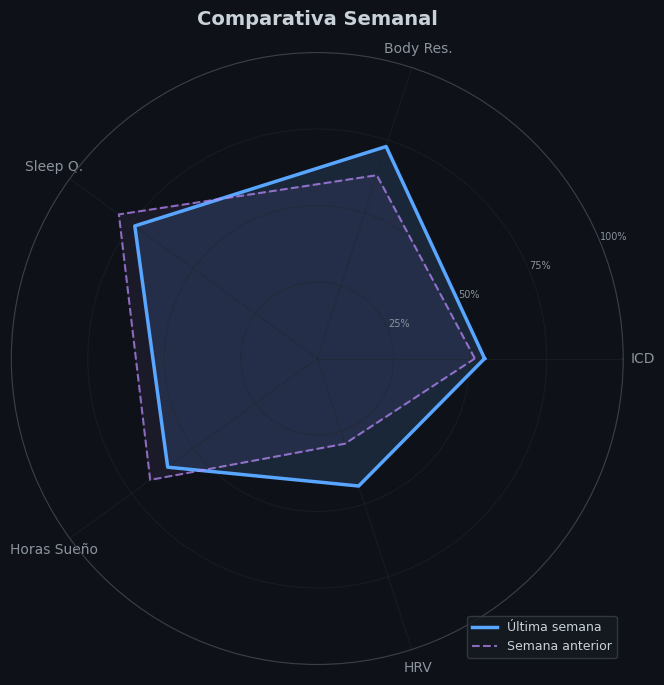


Comparativa semanal (medias):
Métrica             Última sem.  Sem. anterior        Δ
───────────────────────────────────────────────────────
ICD                        54.7           51.5     +3.2
Body Res.                  72.9           63.0     +9.9
Sleep Q.                   73.7           80.1     -6.4
Horas Sueño                 7.2            8.1     -0.8
HRV                        60.7           50.5    +10.2


In [9]:
# Métricas normalizadas 0-1 para radar
radar_cols = {
    'icd_score': ('ICD', 0, 100),
    'body_resources': ('Body Res.', 0, 100),
    'sleep_quality': ('Sleep Q.', 0, 100),
    'sleep_hours': ('Horas Sueño', 0, 12),
    'hrv_rmssd': ('HRV', 30, 100),
}

# Última semana vs semana anterior
today_ts = pd.Timestamp(date.today())
last_7 = df[df.index > today_ts - timedelta(days=7)]
prev_7 = df[(df.index <= today_ts - timedelta(days=7)) & (df.index > today_ts - timedelta(days=14))]

categories = [v[0] for v in radar_cols.values()]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def get_radar_values(subset: pd.DataFrame) -> list:
    vals = []
    for col, (_, lo, hi) in radar_cols.items():
        mean_val = subset[col].mean()
        if np.isnan(mean_val):
            vals.append(0)
        else:
            normalized = (mean_val - lo) / (hi - lo)
            vals.append(max(0, min(1, normalized)))
    vals += vals[:1]
    return vals

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_facecolor('#0e1117')

# Dibujar semana actual
vals_current = get_radar_values(last_7)
ax.plot(angles, vals_current, color=C_ACCENT, linewidth=2.5, label='Última semana')
ax.fill(angles, vals_current, color=C_ACCENT, alpha=0.15)

# Dibujar semana anterior (si hay datos)
if not prev_7.empty:
    vals_prev = get_radar_values(prev_7)
    ax.plot(angles, vals_prev, color=C_PURPLE, linewidth=1.5, linestyle='--', label='Semana anterior', alpha=0.7)
    ax.fill(angles, vals_prev, color=C_PURPLE, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7, color='#8b949e')
ax.set_title('Comparativa Semanal', pad=20)
ax.legend(loc='lower right', fontsize=9, facecolor='#161b22', edgecolor='#3a3f4b')

# Gridlines
ax.spines['polar'].set_color('#3a3f4b')
ax.grid(color='#21262d', alpha=0.5)

plt.tight_layout()
plt.show()

# Imprimir comparativa numérica
print('\nComparativa semanal (medias):')
print(f'{"Métrica":<18} {"Última sem.":>12} {"Sem. anterior":>14} {"Δ":>8}')
print('─' * 55)
for col, (name, _, _) in radar_cols.items():
    curr = last_7[col].mean()
    prev = prev_7[col].mean() if not prev_7.empty else np.nan
    d = curr - prev if not np.isnan(prev) else np.nan
    d_str = f'{d:+.1f}' if not np.isnan(d) else 'N/A'
    print(f'{name:<18} {curr:>12.1f} {(f"{prev:.1f}" if not np.isnan(prev) else "N/A"):>14} {d_str:>8}')